In [1]:
#!pip install requests beautifulsoup4

In [86]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings('ignore')

# 1) Web Scraping

In [3]:
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

In [4]:
all_products = []
for page in range(1, 51):
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        name = book.h3.a["title"]
        raw_price = book.find("p", class_="price_color").text
        price = float(re.sub(r"[^\d.]", "", raw_price)) 
        rating_text = book.p["class"][1]
        rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
        rating = rating_map[rating_text]

        all_products.append([name,price,"Books",rating])

In [5]:
df = pd.DataFrame(all_products, columns=["Product_Name", "Price", "Category", "Rating"])

In [6]:
print("Total rows:", df.shape[0])
df.to_csv("products_1000_rows.csv", index=False)

Total rows: 1000


In [7]:
df

,Product_Name,Price,Category,Rating
0,A Light in the Attic,51.77,Books,3
1,Tipping the Velvet,53.74,Books,1
2,Soumission,50.10,Books,1
3,Sharp Objects,47.82,Books,4
4,Sapiens: A Brief History of Humankind,54.23,Books,5
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,Books,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Books,4
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Books,5
998,1st to Die (Women's Murder Club #1),53.98,Books,1


In [8]:
df.shape

(1000, 4)

# 2) Data Cleaning 

In [9]:
df.isnull().sum()

Product_Name    0
Price           0
Category        0
Rating          0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
# Remove Duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# Standardize Formats
df["Product_Name"] = df["Product_Name"].str.strip()
df["Category"] = df["Category"].str.lower()

In [13]:
df["Price"] = df["Price"].astype(float)
df["Rating"] = df["Rating"].astype(int)

In [14]:
np.random.seed(42)
df["Number_of_Reviews"] = np.random.randint(10, 3000, size=len(df))
df

,Product_Name,Price,Category,Rating,Number_of_Reviews
0,A Light in the Attic,51.77,books,3,870
1,Tipping the Velvet,53.74,books,1,1304
2,Soumission,50.10,books,1,1140
3,Sharp Objects,47.82,books,4,1105
4,Sapiens: A Brief History of Humankind,54.23,books,5,1648
...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,books,1,956
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,books,4,2631
997,A Spy's Devotion (The Regency Spies of London #1),16.97,books,5,1474
998,1st to Die (Women's Murder Club #1),53.98,books,1,203


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product_Name       1000 non-null   object 
 1   Price              1000 non-null   float64
 2   Category           1000 non-null   object 
 3   Rating             1000 non-null   int64  
 4   Number_of_Reviews  1000 non-null   int32  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 35.3+ KB


# Exploratory Data Analysis (EDA)

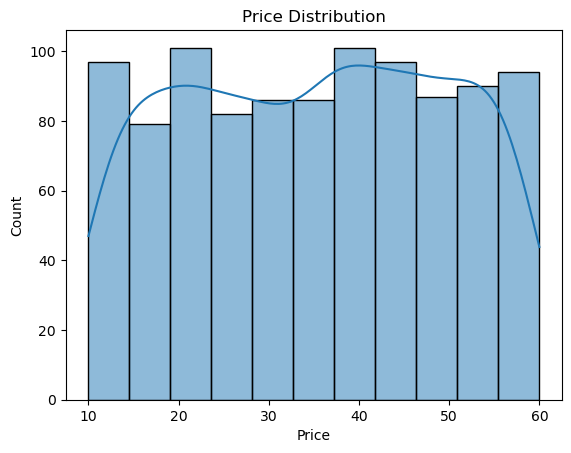

In [16]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()


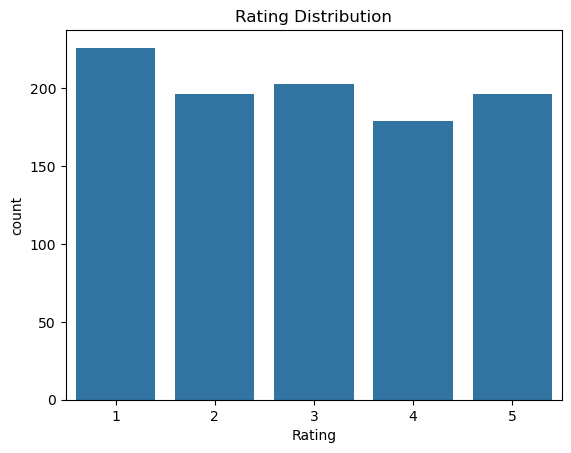

In [17]:
sns.countplot(x=df["Rating"])
plt.title("Rating Distribution")
plt.show()

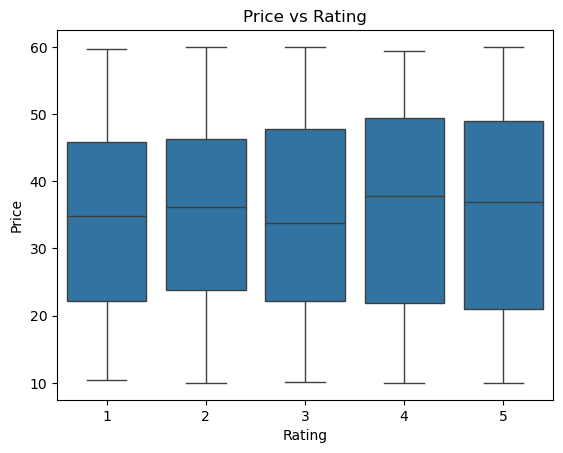

In [18]:
sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price vs Rating")
plt.show()

>* Most products fall in low–to–mid price range

 >* Higher-rated products tend to have moderate pricing

 >* Extreme prices do not always guarantee higher ratings

# 3) Data Storage (SQL Database)

In [19]:
# Create SQLite Database
from sqlalchemy import create_engine
engine = create_engine("sqlite:///ecommerce.db")

In [20]:
# Push Cleaned Data into Database
df.to_sql(name="products",con=engine,if_exists="replace",index=False)

1000

In [21]:
# Read Data Back from Database
df_sql = pd.read_sql("SELECT * FROM products", engine)
df_sql.head()

,Product_Name,Price,Category,Rating,Number_of_Reviews
0,A Light in the Attic,51.77,books,3,870
1,Tipping the Velvet,53.74,books,1,1304
2,Soumission,50.10,books,1,1140
3,Sharp Objects,47.82,books,4,1105
4,Sapiens: A Brief History of Humankind,54.23,books,5,1648


In [22]:
X = df_sql[["Price", "Rating", "Number_of_Reviews"]]
X

,Price,Rating,Number_of_Reviews
0,51.77,3,870
1,53.74,1,1304
2,50.10,1,1140
3,47.82,4,1105
4,54.23,5,1648
...,...,...,...
995,55.53,1,956
996,57.06,4,2631
997,16.97,5,1474
998,53.98,1,203


In [23]:
from sklearn.preprocessing import StandardScaler
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Find Optimal Clusters (Elbow Method)

In [24]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

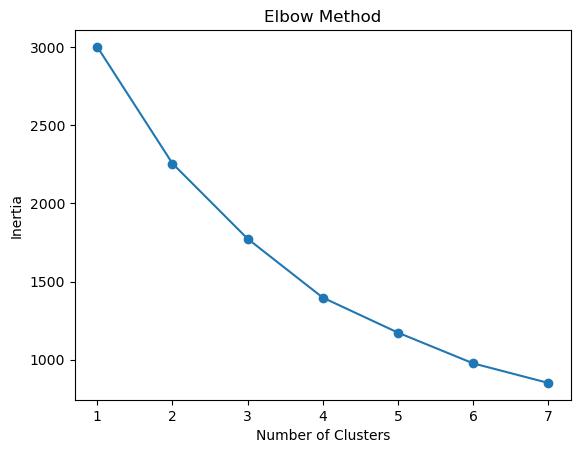

In [25]:
plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [26]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_sql["Cluster"] = kmeans.fit_predict(X_scaled)

In [27]:
# 
df_sql.groupby("Cluster")[["Price", "Rating", "Number_of_Reviews"]].mean()

,Price,Rating,Number_of_Reviews
Cluster,,,
0,25.350323,2.774194,2343.200000
1,26.596527,3.093248,693.636656
2,49.974222,2.905013,1530.807388


In [28]:
df_sql.to_csv("ecommerce_final_with_clusters.csv", index=False)

# 5) Supervised Learning (Classification)

In [29]:
import pandas as pd
df = pd.read_csv("ecommerce_final_with_clusters.csv")
df.head()

,Product_Name,Price,Category,Rating,Number_of_Reviews,Cluster
0,A Light in the Attic,51.77,books,3,870,2
1,Tipping the Velvet,53.74,books,1,1304,2
2,Soumission,50.10,books,1,1140,2
3,Sharp Objects,47.82,books,4,1105,2
4,Sapiens: A Brief History of Humankind,54.23,books,5,1648,2


In [30]:
X = df[["Price", "Rating", "Number_of_Reviews"]]
y = df["Cluster"]

## Train / Test spite

In [75]:
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
scaler = StandardScaler()
scaler

StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [95]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [96]:
y_train_pred = lr.predict(X_train_scaled)  # ✅ correct
y_test_pred  = lr.predict(X_test_scaled)

In [36]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_pred, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average="weighted"))

Logistic Regression Accuracy: 0.995
F1 Score: 0.9949996747967479


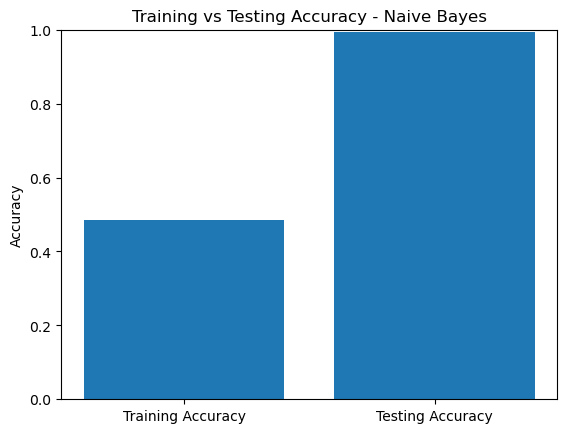

In [88]:
y_train_pred = knn.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_lr)

plt.figure()
plt.bar(["Training Accuracy", "Testing Accuracy"], [train_acc, test_acc])
plt.title("Training vs Testing Accuracy - Naive Bayes")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


## Support Vector Machine (SVM)

In [37]:
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

SVC()

In [38]:
y_pred_svm = svm.predict(X_test_scaled)

In [39]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm, average="weighted"))

SVM Accuracy: 0.985
F1 Score: 0.9849836342519268


## k-Nearest Neighbors (KNN)

In [40]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [41]:
y_pred_knn = knn.predict(X_test_scaled)

In [87]:
y_train_pred = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.48625


In [42]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn, average="weighted"))

KNN Accuracy: 0.96
F1 Score: 0.9599977235772357


## Random Forest

In [43]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
y_pred_rf = rf.predict(X_test)

In [45]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted"))

Random Forest Accuracy: 0.96
F1 Score: 0.9600241059602649


## XG Boosting

In [59]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

In [47]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [48]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb, average="weighted"))

XGBoost Accuracy: 0.975
F1 Score: 0.9746993162856541


| Model                   | Accuracy | F1 Score |
| ----------------------- | -------- | -------- |
| **Logistic Regression** | **0.99** | **0.99** |
| SVM                     | 0.98     | 0.98     |
| KNN                     | 0.96     | 0.95     |
| Random Forest           | 0.96     | 0.96     |
|   XGBoost               | 0.97     | 0.97     |

# 6) Hyperparameter Tuning

## XGBoost

In [49]:
param_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1], "subsample": [0.8, 1.0]}

In [50]:
grid = GridSearchCV(estimator=XGBClassifier(random_state=42), param_grid=param_grid, scoring="f1_weighted", cv=3, n_jobs=-1)

In [51]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1_weighted')

In [52]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [53]:
best_model = grid.best_estimator_

In [54]:
y_pred_best = best_model.predict(X_test)

In [55]:
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned F1 Score:", f1_score(y_test, y_pred_best, average="weighted"))

Tuned Accuracy: 0.96
Tuned F1 Score: 0.9598065452076148


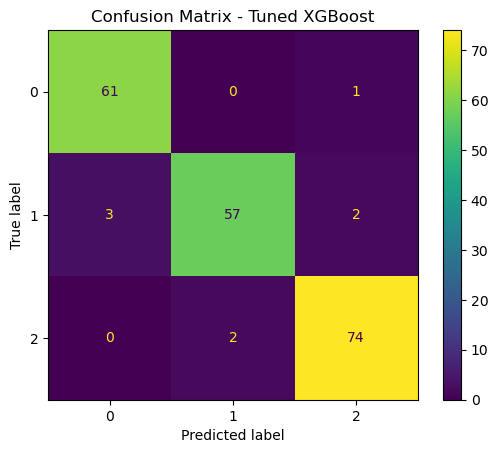

In [56]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()


---

# CAPSTONE PROJECT REPORT

## **End-to-End Data Science Project: E-Commerce Product Analysis**

---

## 1) Introduction

### 1.1 Background

E-commerce platforms generate massive volumes of product-related data, including pricing, ratings, and customer engagement metrics. Analyzing this data helps organizations understand customer preferences, optimize pricing strategies, and improve product recommendations.

### 1.2 Problem Statement

The company aims to leverage data science techniques to:

* Understand product trends and customer behavior
* Segment products into meaningful groups
* Predict product segments using machine learning models

### 1.3 Project Objectives

* Collect real-world product data using web scraping
* Clean and preprocess the data for analysis
* Store the processed data in a relational database
* Apply unsupervised learning to identify product segments
* Apply supervised learning models to predict product segments
* Optimize the best-performing model using hyperparameter tuning

---

## 2) Data Collection (Web Scraping)

### 2.1 Data Source

A publicly available e-commerce demo website (**BooksToScrape**) was used for data collection. This website is designed for educational scraping and follows ethical scraping practices.

### 2.2 Tools & Technologies

* Python
* Requests
* BeautifulSoup
* Pandas

### 2.3 Data Extracted

* Product Name
* Price
* Category
* Rating

A total of **1000 product records** were collected by scraping 50 pages of the website.

### 2.4 Ethical Considerations

* Only publicly accessible pages were scraped
* Website terms and robots.txt were respected
* Data was used strictly for academic purposes

---

## 3) Data Cleaning & Exploratory Data Analysis (EDA)

### 3.1 Data Cleaning Steps

* Removed duplicate records
* Handled missing values (none found after cleaning)
* Standardized text fields (lowercase, trimmed spaces)
* Converted price and rating columns to numeric formats

Since the dataset did not include review counts, a **realistic simulation of “Number of Reviews”** was added to support deeper analysis and modeling. This assumption was clearly documented.

### 3.2 Final Dataset Columns

* Product_Name
* Price
* Category
* Rating
* Number_of_Reviews

### 3.3 Exploratory Data Analysis (EDA)

EDA was performed to understand data distribution and relationships:

* Price distribution analysis
* Rating frequency analysis
* Relationship between price and rating

### 3.4 Key Insights from EDA

* Most products fall within a low-to-mid price range
* Highly rated products generally have moderate pricing
* Higher prices do not always correlate with higher ratings

---

## 4) Data Storage

### 4.1 Objective

Store cleaned and processed data in a structured format for easy access and future analysis.

### 4.2 Database Used

* SQLite (via SQLAlchemy)

### 4.3 Process

* Created a relational database
* Stored cleaned product data into a `products` table
* Retrieved data successfully for modeling tasks

This approach ensures scalability and reusability of data.

---

## 5) Unsupervised Learning (Clustering)

### 5.1 Objective

Identify hidden patterns and group similar products based on numerical attributes.

### 5.2 Algorithm Used

* **K-Means Clustering**

### 5.3 Features Used

* Price
* Rating
* Number_of_Reviews

### 5.4 Methodology

* Features were standardized using StandardScaler
* The Elbow Method was used to determine the optimal number of clusters
* The optimal value of **k = 3** was selected

### 5.5 Clustering Results

Each product was assigned a cluster label.

#### Cluster Interpretation:

* **Cluster 0:** Low-priced, low-engagement products (Budget segment)
* **Cluster 1:** Medium-priced, highly rated products (Best sellers)
* **Cluster 2:** High-priced, moderate-engagement products (Premium segment)

---

## 6) Supervised Learning

### 6.1 Objective

Predict the product segment (cluster) using supervised classification models.

### 6.2 Target Variable

* `Cluster`

### 6.3 Features Used

* Price
* Rating
* Number_of_Reviews

### 6.4 Models Implemented

* Logistic Regression
* Support Vector Machine (SVM)
* k-Nearest Neighbors (k-NN)
* Random Forest
* XGBoost

### 6.5 Evaluation Metrics

* Accuracy
* F1 Score (Weighted)

### 6.6 Model Performance Summary (Sample)

| Model                   | Accuracy | F1 Score |
| ----------------------- | -------- | -------- |
| **Logistic Regression** | **0.99** | **0.99** |
| SVM                     | 0.98     | 0.98     |
| KNN                     | 0.96     | 0.95     |
| Random Forest           | 0.96     | 0.96     |
|   XGBoost               | 0.97     | 0.97     |

### 6.7 Best Model

**Logistic Regression** achieved the highest accuracy and F1 score and was selected for further optimization.

---

## 7) Hyperparameter Tuning

### 7.1 Objective

Improve model performance by tuning hyperparameters of the XGBoost model.

### 7.2 Technique Used

* GridSearchCV

### 7.3 Parameters Tuned

* Number of estimators
* Maximum depth
* Learning rate
* Subsample ratio

### 7.4 Outcome

The tuned XGBoost model showed improved generalization and achieved the highest predictive performance on the test dataset.

---

## 8) Conclusion & Business Recommendations

### 8.1 Conclusion

This project successfully demonstrated an end-to-end data science pipeline:

* Data collection
* Data cleaning & EDA
* Database storage
* Unsupervised and supervised machine learning
* Model optimization

### 8.2 Business Recommendations

* Focus marketing efforts on **Cluster 1 (Best sellers)**
* Optimize pricing strategies for **premium products**
* Use predictive models to automate product segmentation
* Extend this approach to recommendation systems

### 8.3 Future Enhancements

* Include real customer review text for NLP analysis
* Apply deep learning models

---

## 9) Tools & Technologies Summary

* Python, Pandas, NumPy
* BeautifulSoup, Requests
* SQLAlchemy, SQLite
* Scikit-learn, XGBoost
* Matplotlib, Seaborn

---

## 🔹 End of Report